In [48]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [ ]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [5]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [7]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [ ]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

-  회귀분석 오차함수 : 
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [ ]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수          옵티마저이저      평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [ ]:
# 학습 전 예측
model.predict(np.array([[0],
                        [0.01]]))

In [ ]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [ ]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                #  독립변수        타겟변수(종속)   학습횟수    학습시출력여부

In [ ]:
hist.history.keys()

In [ ]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [ ]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

In [ ]:
model.save('model/after_learning.h5')

In [8]:
# 모델 load
from tensorflow.keras.models import load_model
model = load_model('model/after_learning.h5')

In [16]:
y_hat = model.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mean square error(mse)

4/4 [==============================] - 0s 670us/step


2.424005006661846e-06

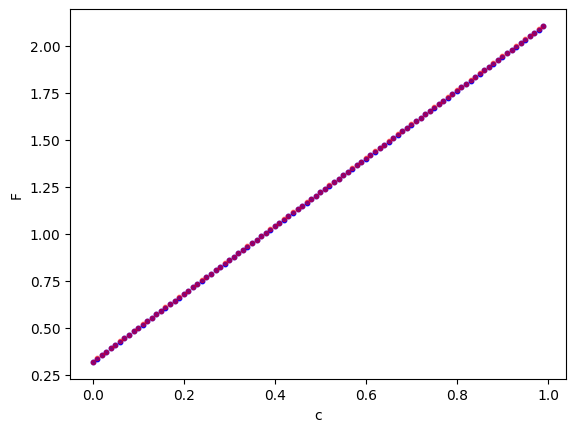

In [22]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', s=10)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', s=10, alpha=0.5)
plt.xlabel('c')
plt.ylabel('F')
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [31]:
# 평균이 0이고 표준편차가 0.1인 넘파이 배열을 생성(size만큼)
np.random.seed(707)
noise = np.random.normal(0, scale=0.1, size=100)
noised_scaled_data_F = noise + scaled_data_F

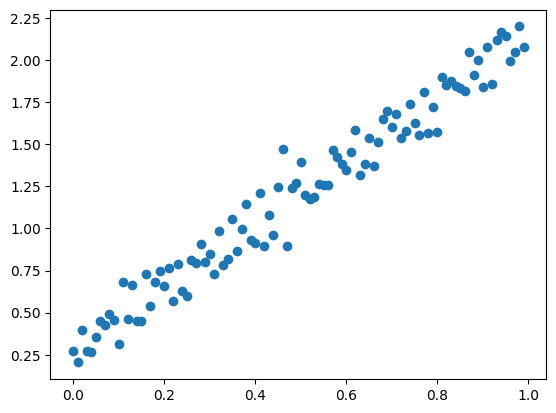

In [34]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [36]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model2 = Sequential()
model2.add(Dense(units=1, input_shape=(1, ))) # units출력갯수, input_shape입력shape
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
                # 손실함수          옵티마이저            평가지표
print(model2.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [37]:
# 5. 학습시키기
hist2 = model2.fit(scaled_data_C, 
                   noised_scaled_data_F,
                   epochs=1000,
                   verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.9457 - mae: 0.8966
Epoch 2/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.9241 - mae: 0.8856
Epoch 3/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.9083 - mae: 0.8773
Epoch 4/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.8952 - mae: 0.8704
Epoch 5/1000
4/4 [==============================] - 0s 831us/step - loss: 0.8832 - mae: 0.8639
Epoch 6/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.8720 - mae: 0.8578
Epoch 7/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.8602 - mae: 0.8515
Epoch 8/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.8492 - mae: 0.8454
Epoch 9/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.8383 - mae: 0.8396
Epoch 10/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.8273 - mae: 0.8335
Epoch 11/1000
4/4 [==============================] - 0s 1ms/step - 

Epoch 88/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.2294 - mae: 0.3995
Epoch 89/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.2253 - mae: 0.3952
Epoch 90/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.2205 - mae: 0.3905
Epoch 91/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.2153 - mae: 0.3850
Epoch 92/1000
4/4 [==============================] - 0s 881us/step - loss: 0.2103 - mae: 0.3801
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.2053 - mae: 0.3751
Epoch 94/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.2016 - mae: 0.3713
Epoch 95/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.1967 - mae: 0.3663
Epoch 96/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.1927 - mae: 0.3623
Epoch 97/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.1889 - mae: 0.3583
Epoch 98/1000
4/4 [==============================] - 0s 2m

4/4 [==============================] - 0s 793us/step - loss: 0.0419 - mae: 0.1722
Epoch 175/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0416 - mae: 0.1718
Epoch 176/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0414 - mae: 0.1713
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0410 - mae: 0.1704
Epoch 178/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0407 - mae: 0.1700
Epoch 179/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0405 - mae: 0.1693
Epoch 180/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0402 - mae: 0.1688
Epoch 181/1000
4/4 [==============================] - 0s 839us/step - loss: 0.0399 - mae: 0.1681
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0396 - mae: 0.1675
Epoch 183/1000
4/4 [==============================] - 0s 794us/step - loss: 0.0393 - mae: 0.1670
Epoch 184/1000
4/4 [==============================] - 0s 84

4/4 [==============================] - 0s 1ms/step - loss: 0.0131 - mae: 0.0952
Epoch 345/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0130 - mae: 0.0950
Epoch 346/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0130 - mae: 0.0947
Epoch 347/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0129 - mae: 0.0945
Epoch 348/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0129 - mae: 0.0943
Epoch 349/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0128 - mae: 0.0942
Epoch 350/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0128 - mae: 0.0941
Epoch 351/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0127 - mae: 0.0938
Epoch 352/1000
4/4 [==============================] - 0s 808us/step - loss: 0.0127 - mae: 0.0936
Epoch 353/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0126 - mae: 0.0935
Epoch 354/1000
4/4 [==============================] - 0s 1ms/st

4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0887
Epoch 431/1000
4/4 [==============================] - 0s 811us/step - loss: 0.0112 - mae: 0.0888
Epoch 432/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0112 - mae: 0.0891
Epoch 433/1000
4/4 [==============================] - 0s 932us/step - loss: 0.0112 - mae: 0.0892
Epoch 434/1000
4/4 [==============================] - 0s 720us/step - loss: 0.0112 - mae: 0.0889
Epoch 435/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0112 - mae: 0.0887
Epoch 436/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0111 - mae: 0.0886
Epoch 437/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0111 - mae: 0.0886
Epoch 438/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0112 - mae: 0.0888
Epoch 439/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0111 - mae: 0.0887
Epoch 440/1000
4/4 [==============================] - 0s 1m

Epoch 516/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 517/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 518/1000
4/4 [==============================] - 0s 718us/step - loss: 0.0110 - mae: 0.0879
Epoch 519/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0881
Epoch 520/1000
4/4 [==============================] - 0s 838us/step - loss: 0.0110 - mae: 0.0879
Epoch 521/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 522/1000
4/4 [==============================] - 0s 999us/step - loss: 0.0110 - mae: 0.0877
Epoch 523/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 524/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 525/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 526/1000
4/4 [========================

Epoch 687/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 688/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0876
Epoch 689/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0876
Epoch 690/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0876
Epoch 691/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0879
Epoch 692/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 693/1000
4/4 [==============================] - 0s 833us/step - loss: 0.0110 - mae: 0.0877
Epoch 694/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 695/1000
4/4 [==============================] - 0s 795us/step - loss: 0.0110 - mae: 0.0877
Epoch 696/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0879
Epoch 697/1000
4/4 [==========================

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 858/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0109 - mae: 0.0877
Epoch 859/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 860/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 861/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 862/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 863/1000
4/4 [==============================] - 0s 695us/step - loss: 0.0110 - mae: 0.0878
Epoch 864/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0109 - mae: 0.0877
Epoch 865/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0109 - mae: 0.0877
Epoch 866/1000
4/4 [==============================] - 0s 803us/step - loss: 0.0110 - mae: 0.0877
Epoch 867/1000
4/4 [==============================] - 0s 801u

Epoch 943/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0879
Epoch 944/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0879
Epoch 945/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0879
Epoch 946/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 947/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 948/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 949/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0880
Epoch 950/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0109 - mae: 0.0877
Epoch 951/1000
4/4 [==============================] - 0s 855us/step - loss: 0.0109 - mae: 0.0877
Epoch 952/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 953/1000
4/4 [============================

In [39]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

Text(0.5, 0, 'epoch')

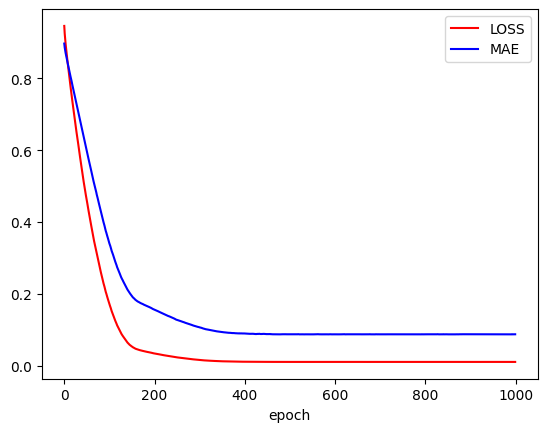

In [41]:
plt.plot(hist2.history['loss'], 'r', label='LOSS')
plt.plot(hist2.history['mae'], 'b', label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [44]:
y_hat = model2.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, noised_scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mse

4/4 [==============================] - 0s 2ms/step


0.010949037977256871

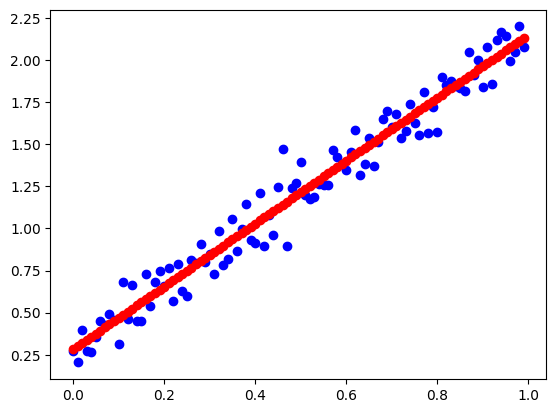

In [47]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='b')
plt.scatter(x=scaled_data_C, y=y_hat, c='r')